In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

In [2]:
# Temel sabitler tanimlanir.
ARTICLES_DATASET_PATH = Path("dataset/ebnerd_demo/articles.parquet")
TRAIN_HISTORY_PATH = Path("dataset/ebnerd_demo/train/history.parquet")
TRAIN_BEHAVIORS_PATH = Path("dataset/ebnerd_demo/train/behaviors.parquet")
MIN_HISTORY_LENGTH = 40
MAX_SAMPLES_PER_CLASS = 2500
TRAIN_RATIO = 0.7
RANDOM_STATE = 42

In [3]:
# Ham verileri yukleyip ozetler.
articles_df = pd.read_parquet(ARTICLES_DATASET_PATH)
train_history_raw_df = pd.read_parquet(TRAIN_HISTORY_PATH)
train_behaviors_raw_df = pd.read_parquet(TRAIN_BEHAVIORS_PATH)
articles_df["title"] = articles_df["title"].fillna("").str.strip()
title_map = articles_df.set_index("article_id")["title"].to_dict()

raw_summary_df = pd.DataFrame(
    {
        "dataset": [
            "articles_df",
            "train_history_raw_df",
            "train_behaviors_raw_df",
        ],
        "rows": [
            len(articles_df),
            len(train_history_raw_df),
            len(train_behaviors_raw_df),
        ],
        "columns": [
            articles_df.shape[1],
            train_history_raw_df.shape[1],
            train_behaviors_raw_df.shape[1],
        ],
    }
)
display(raw_summary_df)

,dataset,rows,columns
0,articles_df,11777,21
1,train_history_raw_df,1590,5
2,train_behaviors_raw_df,24724,17


In [4]:
# History metnini ve split alanini hazirlar.
def array_to_list(values):
    if values is None:
        return []
    if isinstance(values, np.ndarray):
        return values.tolist()
    if isinstance(values, (list, tuple, set)):
        return list(values)
    return []


def build_history_text(article_ids):
    history_titles = []
    for article_id in article_ids:
        title = title_map.get(int(article_id), "")
        if title:
            history_titles.append(title)
    return " ".join(history_titles)


history_df = train_history_raw_df.copy()
history_df["history_article_ids"] = history_df["article_id_fixed"].apply(array_to_list)
history_df["history_len"] = history_df["history_article_ids"].apply(len)
history_df = history_df.loc[history_df["history_len"] >= MIN_HISTORY_LENGTH].copy()
history_df["history_text"] = history_df["history_article_ids"].apply(build_history_text)

behaviors_df = train_behaviors_raw_df.copy()
behaviors_df["article_ids_inview"] = behaviors_df["article_ids_inview"].apply(array_to_list)
behaviors_df["article_ids_clicked"] = behaviors_df["article_ids_clicked"].apply(array_to_list)
behaviors_df["impression_time"] = pd.to_datetime(behaviors_df["impression_time"])
behaviors_df = behaviors_df.merge(
    history_df[["user_id", "history_article_ids", "history_len", "history_text"]],
    on="user_id",
    how="inner",
)
behaviors_df = behaviors_df.sort_values(["user_id", "impression_time", "impression_id"]).copy()
behaviors_df["user_row_index"] = behaviors_df.groupby("user_id").cumcount()
behaviors_df["user_row_count"] = behaviors_df.groupby("user_id")["impression_id"].transform("size")
behaviors_df["split"] = "test"
behaviors_df.loc[
    behaviors_df["user_row_index"] < (behaviors_df["user_row_count"] * TRAIN_RATIO).astype(int),
    "split",
] = "train"

behavior_summary_df = pd.DataFrame(
    {
        "metric": [
            "filtered_rows",
            "unique_users",
            "train_rows",
            "test_rows",
        ],
        "value": [
            len(behaviors_df),
            behaviors_df["user_id"].nunique(),
            int((behaviors_df["split"] == "train").sum()),
            int((behaviors_df["split"] == "test").sum()),
        ],
    }
)
display(behavior_summary_df)

,metric,value
0,filtered_rows,22314
1,unique_users,1140
2,train_rows,15092
3,test_rows,7222


In [5]:
# Bazi kullanici history orneklerini gosterir.
example_user_ids = behaviors_df["user_id"].drop_duplicates().head(3)
user_history_examples_df = behaviors_df.loc[
    behaviors_df["user_id"].isin(example_user_ids),
    ["user_id", "impression_time", "split", "history_article_ids"],
].copy()
user_history_examples_df["history_news_ids_preview"] = user_history_examples_df["history_article_ids"].apply(
    lambda ids: " ".join(str(article_id) for article_id in ids[:12])
)
user_history_examples_df = user_history_examples_df[
    ["user_id", "impression_time", "split", "history_news_ids_preview"]
].head(9)
display(user_history_examples_df)

,user_id,impression_time,split,history_news_ids_preview
22079,11313,2023-05-22 06:30:45,train,9737535 9738334 9738292 9733713 9740161 974017...
22080,11313,2023-05-22 06:32:43,train,9737535 9738334 9738292 9733713 9740161 974017...
18737,11313,2023-05-23 06:26:51,train,9737535 9738334 9738292 9733713 9740161 974017...
18736,11313,2023-05-23 06:38:52,train,9737535 9738334 9738292 9733713 9740161 974017...
10603,11313,2023-05-23 08:11:22,train,9737535 9738334 9738292 9733713 9740161 974017...
17884,11313,2023-05-24 06:36:26,test,9737535 9738334 9738292 9733713 9740161 974017...
21450,11313,2023-05-24 07:24:32,test,9737535 9738334 9738292 9733713 9740161 974017...
14424,11313,2023-05-25 06:28:25,test,9737535 9738334 9738292 9733713 9740161 974017...
17376,13538,2023-05-18 12:38:24,train,9738663 9738569 9738663 9738490 9738663 973866...


In [6]:
# Train ve test icin ornek limitlerini belirler.
max_train_samples = int(MAX_SAMPLES_PER_CLASS * TRAIN_RATIO)
max_test_samples = MAX_SAMPLES_PER_CLASS - max_train_samples
sample_limits = {
    "train": {"clicked": max_train_samples, "not_clicked": max_train_samples},
    "test": {"clicked": max_test_samples, "not_clicked": max_test_samples},
}
samples = {
    "train": {"clicked": [], "not_clicked": []},
    "test": {"clicked": [], "not_clicked": []},
}

sample_limits_df = pd.DataFrame(
    [
        {"split": split, "label": label, "limit": sample_limits[split][label]}
        for split in sample_limits
        for label in sample_limits[split]
    ]
)
display(sample_limits_df)

,split,label,limit
0,train,clicked,1750
1,train,not_clicked,1750
2,test,clicked,750
3,test,not_clicked,750


In [7]:
# Siniflandirma orneklerini toplar.
sample_source = behaviors_df[["split", "history_text", "article_ids_inview", "article_ids_clicked"]]

for row in sample_source.itertuples(index=False):
    split = row.split
    history_text = row.history_text
    clicked_ids = {int(article_id) for article_id in row.article_ids_clicked}

    for article_id in row.article_ids_inview:
        article_id = int(article_id)
        candidate_title = title_map.get(article_id, "")

        if not candidate_title:
            continue

        target_label = "clicked" if article_id in clicked_ids else "not_clicked"

        if len(samples[split][target_label]) >= sample_limits[split][target_label]:
            continue

        combined_text = f"{history_text} {candidate_title}".strip()
        row_data = (article_id, candidate_title, history_text, combined_text, target_label, split)
        samples[split][target_label].append(row_data)

    if all(
        len(samples[current_split][current_label]) >= sample_limits[current_split][current_label]
        for current_split in sample_limits
        for current_label in sample_limits[current_split]
    ):
        break

In [8]:
# Son interaction tablosunu olusturur.
interaction_df = pd.DataFrame(
    samples["train"]["clicked"]
    + samples["train"]["not_clicked"]
    + samples["test"]["clicked"]
    + samples["test"]["not_clicked"],
    columns=[
        "article_id",
        "candidate_title",
        "history_text",
        "text",
        "label",
        "split",
    ],
).reset_index(drop=True)

interaction_preview_df = interaction_df.assign(
    history_preview=interaction_df["history_text"].str.slice(0, 120)
)[["split", "article_id", "candidate_title", "history_preview", "label"]].head()
display(interaction_preview_df)

,split,article_id,candidate_title,history_preview,label
0,train,9775567,Holger Rune rykker op,Efter bizart pressemøde: Holger blander sig Da...,clicked
1,train,9775489,Mexico hæver alarmniveauet for farlig vulkan,Efter bizart pressemøde: Holger blander sig Da...,clicked
2,train,9776715,Kassevogn kører ind i hegn ved Det Hvide Hus,Efter bizart pressemøde: Holger blander sig Da...,clicked
3,train,9776855,DMI afblæser risiko for skybrud,Efter bizart pressemøde: Holger blander sig Da...,clicked
4,train,9776897,Regeringen præsenterer ny sundhedspakke,Efter bizart pressemøde: Holger blander sig Da...,clicked


In [9]:
# Metin ve normalization hazirligini yapar.
train_df = interaction_df.loc[interaction_df["split"] == "train"].reset_index(drop=True)
test_df = interaction_df.loc[interaction_df["split"] == "test"].reset_index(drop=True)
train_texts = train_df["text"].tolist()
test_texts = test_df["text"].tolist()
train_labels = train_df["label"].tolist()
test_labels = test_df["label"].tolist()
texts = train_texts + test_texts
labels = train_labels + test_labels


def load_danish_nlp():
    try:
        return spacy.load("da_core_news_sm", disable=["parser", "ner"]), "da_core_news_sm"
    except OSError:
        return spacy.blank("da"), "spacy.blank('da')"


analyzer, analyzer_name = load_danish_nlp()
stop_words = analyzer.Defaults.stop_words


def normalize_text(text):
    doc = analyzer(text)
    normalized_tokens = []
    for token in doc:
        lemma = token.lemma_.lower().strip() if token.lemma_ else ""
        normalized = lemma if lemma and lemma != "-pron-" else token.lower_
        if token.is_alpha and normalized not in stop_words:
            normalized_tokens.append(normalized)
    return " ".join(normalized_tokens)


text_setup_df = pd.DataFrame(
    {
        "metric": [
            "train_text_count",
            "test_text_count",
            "unique_labels",
            "stop_word_count",
            "language_pipeline",
        ],
        "value": [
            len(train_texts),
            len(test_texts),
            len(set(labels)),
            len(stop_words),
            analyzer_name,
        ],
    }
)
display(text_setup_df)

,metric,value
0,train_text_count,3500
1,test_text_count,1500
2,unique_labels,2
3,stop_word_count,219
4,language_pipeline,spacy.blank('da')


In [10]:
# Tum metinleri normalize eder.
train_cleaned_texts = [
    normalize_text(text) for text in tqdm(train_texts, desc="Train normalization", unit="text")
]
test_cleaned_texts = [
    normalize_text(text) for text in tqdm(test_texts, desc="Test normalization", unit="text")
]
cleaned_texts = train_cleaned_texts + test_cleaned_texts

Train normalization:   0%|          | 0/3500 [00:00<?, ?text/s]

Test normalization:   0%|          | 0/1500 [00:00<?, ?text/s]

In [11]:
# Normalization orneklerini gosterir.
sample_lemma_df = pd.DataFrame(
    {
        "split": interaction_df["split"].head(5),
        "candidate_title": interaction_df["candidate_title"].head(5),
        "history_preview": interaction_df["history_text"].str.slice(0, 120).head(5),
        "normalized_text": cleaned_texts[:5],
        "label": labels[:5],
    }
)
display(sample_lemma_df)

,split,candidate_title,history_preview,normalized_text,label
0,train,Holger Rune rykker op,Efter bizart pressemøde: Holger blander sig Da...,bizart pressemøde holger blander dansk aktie b...,clicked
1,train,Mexico hæver alarmniveauet for farlig vulkan,Efter bizart pressemøde: Holger blander sig Da...,bizart pressemøde holger blander dansk aktie b...,clicked
2,train,Kassevogn kører ind i hegn ved Det Hvide Hus,Efter bizart pressemøde: Holger blander sig Da...,bizart pressemøde holger blander dansk aktie b...,clicked
3,train,DMI afblæser risiko for skybrud,Efter bizart pressemøde: Holger blander sig Da...,bizart pressemøde holger blander dansk aktie b...,clicked
4,train,Regeringen præsenterer ny sundhedspakke,Efter bizart pressemøde: Holger blander sig Da...,bizart pressemøde holger blander dansk aktie b...,clicked


In [12]:
# Etiketleri ve TF-IDF matrisini olusturur.
le = LabelEncoder()
y_train = le.fit_transform(train_labels)
y_test = le.transform(test_labels)
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_cleaned_texts)
X_test = vectorizer.transform(test_cleaned_texts)
feature_names = vectorizer.get_feature_names_out()

vector_summary_df = pd.DataFrame(
    {
        "metric": ["X_train_rows", "X_test_rows", "X_cols", "label_0", "label_1"],
        "value": [X_train.shape[0], X_test.shape[0], X_train.shape[1], le.classes_[0], le.classes_[1]],
    }
)
display(vector_summary_df)

,metric,value
0,X_train_rows,3500
1,X_test_rows,1500
2,X_cols,5000
3,label_0,clicked
4,label_1,not_clicked


In [13]:
# Bazi TF ve TF-IDF agirliklarini gosterir.
sample_doc_idx = 0
sample_tokens = pd.Series(train_cleaned_texts[sample_doc_idx].split())
sample_tf_df = sample_tokens.value_counts().rename_axis("term").reset_index(name="raw_count")
sample_tf_df["tf_weight"] = sample_tf_df["raw_count"] / sample_tf_df["raw_count"].sum()
sample_tfidf_series = pd.Series(
    X_train[sample_doc_idx].toarray().ravel(), index=feature_names, name="tfidf_weight"
)
sample_tf_tfidf_df = sample_tf_df.merge(
    sample_tfidf_series[sample_tfidf_series > 0].reset_index().rename(columns={"index": "term"}),
    on="term",
    how="left",
).sort_values(["tfidf_weight", "tf_weight"], ascending=False).head(10)
display(sample_tf_tfidf_df)

,term,raw_count,tf_weight,tfidf_weight
2,weekend,4,0.012158,0.309018
15,lunar,2,0.006079,0.191152
16,rekordstort,2,0.006079,0.191152
43,solrig,2,0.006079,0.182591
45,varm,2,0.006079,0.158992
18,ukraines,2,0.006079,0.137571
19,modoffensiv,2,0.006079,0.137571
25,gerningsmanden,2,0.006079,0.124726
27,fuld,2,0.006079,0.123993
42,tør,2,0.006079,0.115135


In [14]:
# Train uzerinde modelleri egitir ve test uzerinde degerlendirir.
knn = KNeighborsClassifier(n_neighbors=5, metric="cosine")
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
cv_knn = cross_val_score(knn, X_train, y_train, cv=10, scoring="accuracy")

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
cv_nb = cross_val_score(nb, X_train, y_train, cv=10, scoring="accuracy")

In [16]:
# Tum model sonuclarini tabloda toplar.
results = pd.DataFrame(
    {
        "KNN": [
            accuracy_score(y_test, y_pred_knn),
            precision_score(y_test, y_pred_knn, average="weighted", zero_division=0),
            recall_score(y_test, y_pred_knn, average="weighted"),
            f1_score(y_test, y_pred_knn, average="weighted", zero_division=0),
            cv_knn.mean(),
        ],
        "Naive Bayes": [
            accuracy_score(y_test, y_pred_nb),
            precision_score(y_test, y_pred_nb, average="weighted", zero_division=0),
            recall_score(y_test, y_pred_nb, average="weighted"),
            f1_score(y_test, y_pred_nb, average="weighted", zero_division=0),
            cv_nb.mean(),
        ],
    },
    index=["Accuracy", "Precision", "Recall", "F1", "CV Accuracy"],
)
display(results)

,KNN,Naive Bayes
Accuracy,0.929333,0.885333
Precision,0.938084,0.885432
Recall,0.929333,0.885333
F1,0.928979,0.885326
CV Accuracy,0.701714,0.728286


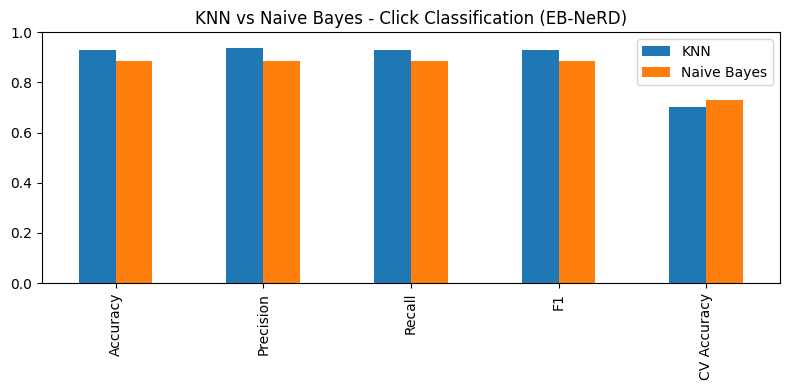

In [17]:
# Sonuc grafigini cizer.
results.plot(kind="bar", figsize=(8, 4))
plt.ylim(0, 1)
plt.title("KNN vs Naive Bayes - Click Classification (EB-NeRD)")
plt.tight_layout()
plt.show()

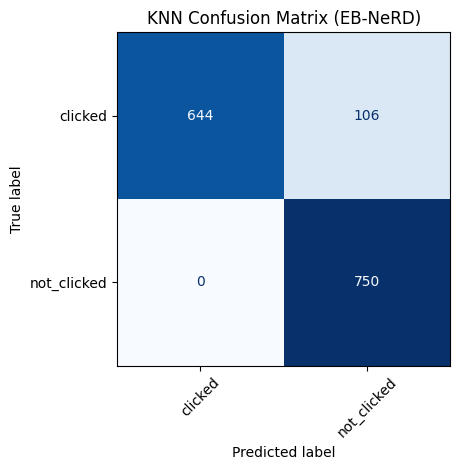

In [18]:
# KNN confusion matrix cizer.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    display_labels=le.classes_,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False,
)

plt.title("KNN Confusion Matrix (EB-NeRD)")
plt.tight_layout()
plt.show()

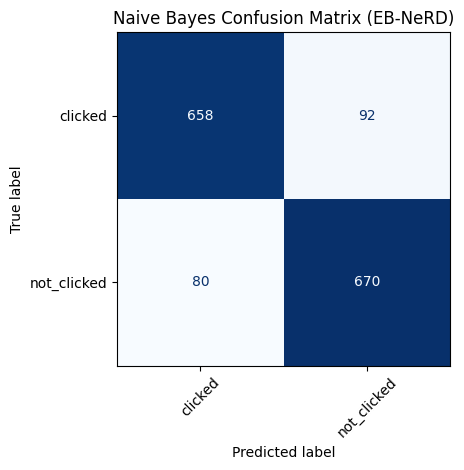

In [19]:
# Naive Bayes confusion matrix cizer.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    display_labels=le.classes_,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False,
)

plt.title("Naive Bayes Confusion Matrix (EB-NeRD)")
plt.tight_layout()
plt.show()